In [5]:
import numpy as np
from scipy.signal import convolve2d, correlate2d
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from Functions.Functions import *

In [241]:
def create_plots(rows, cols, image_list, row_list=None, col_list=None,
                 figsize_per_image=(3, 3), title_fontsize=15, label_fontsize=15):
    """
    Display images in a grid with optional row and column titles.
    Column titles are placed on the top row (via set_title).
    Row titles are added as rotated figure text on the left.
    """

    fig, axes = plt.subplots(rows, cols, figsize=(cols * figsize_per_image[0],
                                                  rows * figsize_per_image[1]))
    axes = np.atleast_2d(axes)

    img_idx = 0
    for r in range(rows):
        for c in range(cols):
            ax = axes[r, c]
            plt.sca(ax)

            if img_idx >= len(image_list):
                ax.axis("off")
                continue

            showgrey(image_list[img_idx], display=False)
            ax.axis("off") 

            # Column titles
            if col_list and r == 0 and c < len(col_list):
                ax.set_title(col_list[c], fontsize=title_fontsize)

            img_idx += 1

    # Add row labels as rotated figure text
    if row_list:
        fig.tight_layout()  # ensure positions are up-to-date before reading bbox
        fig.canvas.draw()   # necessary to get correct positions in some backends

        # Find the leftmost x position of the first column
        left_edge = min(ax.get_position().x0 for ax in axes[:, 0])
        x_text = left_edge - 0.02  # small offset to the left

        for r, label in enumerate(row_list[:rows]):
            ax0 = axes[r, 0]
            bbox = ax0.get_position()
            ycenter = (bbox.y0 + bbox.y1) / 2
            plt.figtext(x_text, ycenter, label, fontsize=label_fontsize,
                        va='center', ha='center', rotation=90)
    else:
        plt.tight_layout()

    plt.show()

## 1. Difference operators

In [ ]:
# central differences
def deltax(im, h=1):
    diff = []
    for i in range((im.shape[0])-h):
        diff_i = (im[i + h, :] - im[i - h, :]) / 2 * h
        diff.append(diff_i)
    
    return np.array(diff)
    # diff = (im_x[h:] - im_x[:-h]) /= 2 * h

In [42]:
def deltay(im, h=1):
    diff = []
    for i in range(im.shape[1]-h):
        diff_i = (im[:, i + h] - im[:, i - h]) / 2 * h
        diff.append(diff_i)

    return np.array(diff)
    

In [14]:
tools = np.load("../DD2423_Python_Labs_1_2/Images-npy/few256.npy")

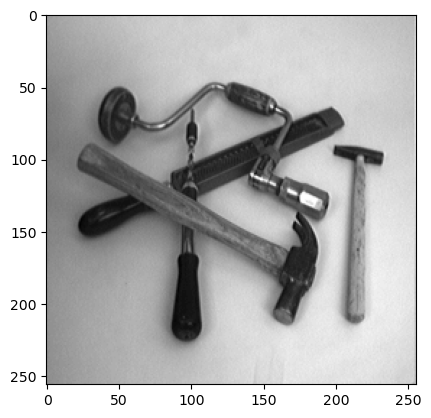

In [9]:
showgrey(tools)

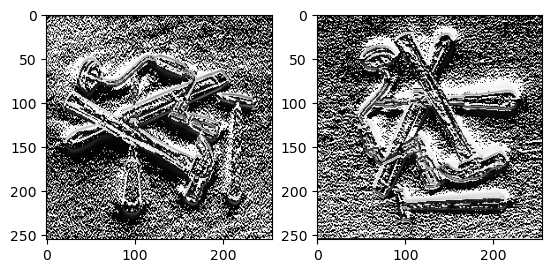

In [ ]:
# TODO kolla varför annorlunda till JPs
# ALSO varför annorlunda n convolution med filter mask??


plt.subplot(1, 2, 1)
diff_x_tools = deltax(tools, h=1)
showgrey(diff_x_tools, display=False)

plt.subplot(1, 2, 2)
diff_y_tools = deltay(tools, h=1)
showgrey(diff_y_tools, display=False)

In [133]:
# for h=1
dxmask = np.zeros((3, 3))
dxmask[1, 0] = 0.5
dxmask[1, 2] = -0.5
print(dxmask)

dymask = np.zeros((3, 3))
dymask[0, 1] = 0.5
dymask[2, 1] = -0.5
print(dymask)

[[ 0.   0.   0. ]
 [ 0.5  0.  -0.5]
 [ 0.   0.   0. ]]
[[ 0.   0.5  0. ]
 [ 0.   0.   0. ]
 [ 0.  -0.5  0. ]]


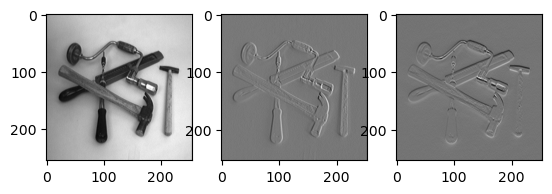

In [ ]:
plt.subplot(1, 3, 1)
showgrey(tools, display=False)

dxtools = convolve2d(tools, dxmask, 'valid')
dytools = convolve2d(tools, dymask, 'valid')

plt.subplot(1, 3, 2)
showgrey(dxtools, display=False)

plt.subplot(1, 3, 3)
showgrey(dytools, display=False)

In [55]:
print("Tools shape: ", tools.shape)
print("Dxtools shape ", dxtools.shape)   # lose first and last pixel


Tools shape:  (256, 256)
Dxtools shape  (254, 254)


## 2. Point–wise thresholding of gradient magnitudes

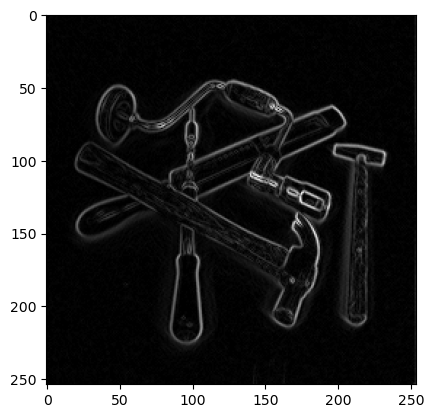

In [59]:
gradmagntools = np.sqrt(dxtools**2 + dytools**2)
showgrey(gradmagntools, display=True)

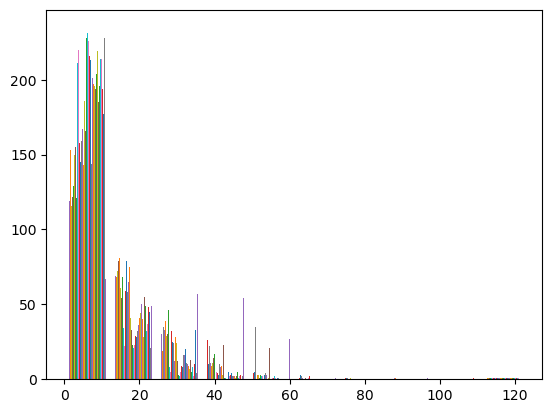

In [99]:
# Compute the histogram of this image (using numpy.histogram()) and use this to guess a threshold that yields reasonably thin edges when applied to gradmagntools

# y-axis: pixels
# x-axel: magnitude
# i.e. how many pixels have a high magnitude (large change)? Not so many have higher than 10-15
np.histogram(gradmagntools)
hist1 = plt.hist(gradmagntools)

In [ ]:
godthem = np.load("../DD2423_Python_Labs_1_2/Images-npy/godthem256.npy")
dxgodthem = convolve2d(godthem, dxmask, 'valid')
dygodthem = convolve2d(godthem, dymask, 'valid')

gradmagngodthem = np.sqrt(dxgodthem**2 + dygodthem**2)
# plt.hist(gradmagngodthem)

In [104]:
def Lv(inpic, dxmask, dymask, shape = 'same'):
    Lx = convolve2d(inpic, dxmask, shape)
    Ly = convolve2d(inpic, dymask, shape)
    return np.sqrt(Lx**2 + Ly**2)

(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)


Text(0.5, 1.0, 'Magnitude with smoothing')

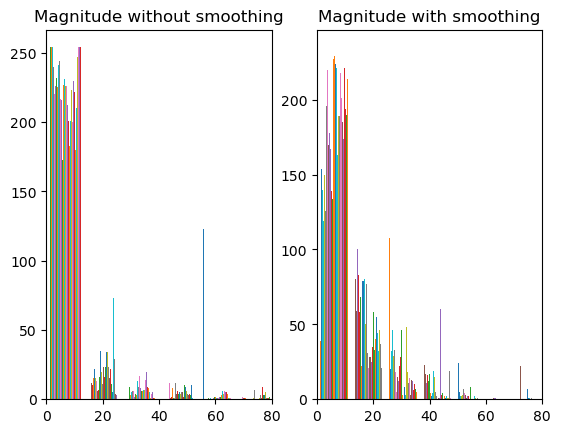

In [ ]:
blurred_godthem = discgaussfft(tools, 1)
blurred_tools = discgaussfft(godthem, 1)

plt.subplot(1,2,1)
plt.hist(Lv(tools, dxmask, dymask))
plt.xlim(0,80)     # zooming in on x axis to see better
plt.title("Magnitude without smoothing")

plt.subplot(1,2,2)
plt.hist(Lv(blurred_tools, dxmask, dymask))
plt.xlim(0,80)     # zooming in on x axis to see better
plt.title("Magnitude with smoothing")

(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)


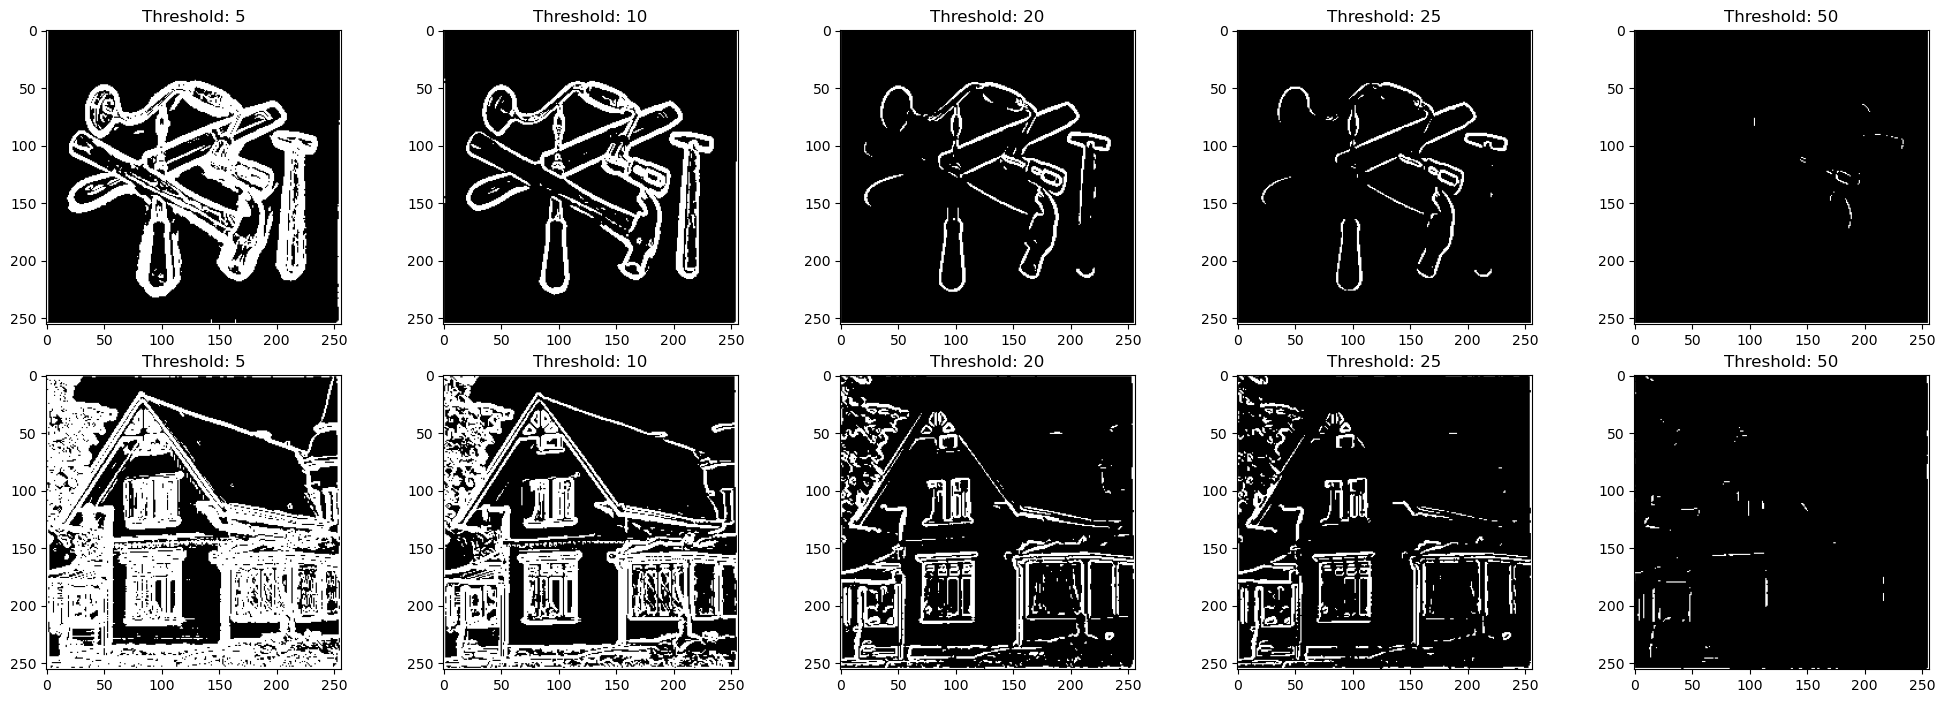

In [ ]:
# reasonably thin edges: tradeoff between connected and thin, where we get thinner edge for higher threshold

gradmagngodthem = Lv(blurred_godthem, dxmask, dymask)
gradmagntools = Lv(blurred_tools, dxmask, dymask)

thresholds = [5, 10, 20, 25, 50]
plt.figure(figsize=(20,15))
for i, threshold in enumerate(thresholds):
    plt.subplot(1, 5, i+1)
    plt.title(f"Threshold: {threshold}")
    showgrey((gradmagntools > threshold).astype(int), display=False)
    
    plt.subplot(2, 5, i+1)
    plt.title(f"Threshold: {threshold}")
    showgrey((gradmagngodthem > threshold).astype(int), display=False)
    

plt.tight_layout() 
plt.show()

In [149]:
# we have the dxmask and dymask already, but we pad it to be 5x5
print(dxmask)
print("\n")

print(dymask)
print("\n")

dxmask_5_5 = np.pad(dxmask.copy(), pad_width=(1, 1), mode='constant')
print(dxmask_5_5)

dymask_5_5 = np.pad(dymask.copy(), pad_width=(1, 1), mode='constant')
print(dymask_5_5)


[[ 0.   0.   0. ]
 [ 0.5  0.  -0.5]
 [ 0.   0.   0. ]]


[[ 0.   0.5  0. ]
 [ 0.   0.   0. ]
 [ 0.  -0.5  0. ]]


[[ 0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.   0.5  0.  -0.5  0. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.   0.   0.   0.   0. ]]
[[ 0.   0.   0.   0.   0. ]
 [ 0.   0.   0.5  0.   0. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.   0.  -0.5  0.   0. ]
 [ 0.   0.   0.   0.   0. ]]


In [150]:
dxxmask = np.zeros((3, 3))

dxxmask[1, 0] = 1
dxxmask[1, 1] = -2
dxxmask[1, 2] = 1

print(dxxmask)
print("\n")

dyymask = dxxmask.transpose()
print(dyymask)

[[ 0.  0.  0.]
 [ 1. -2.  1.]
 [ 0.  0.  0.]]


[[ 0.  1.  0.]
 [ 0. -2.  0.]
 [ 0.  1.  0.]]


In [138]:
dxxmask_5_5 = np.zeros((5, 5))

dxxmask_5_5[2, 1] = 1
dxxmask_5_5[2, 2] = -2
dxxmask_5_5[2, 3] = 1

print(dxxmask_5_5)
print("\n")

dyymask_5_5 = dxxmask_5_5.transpose()
print(dyymask_5_5)


[[ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  1. -2.  1.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]


[[ 0.  0.  0.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0. -2.  0.  0.]
 [ 0.  0.  1.  0.  0.]
 [ 0.  0.  0.  0.  0.]]


In [208]:
def Lvvtilde(L, shape = 'same'):
    # L is a gaussian blurred image
    Lx = convolve2d(L, dxmask_5_5, shape)
    Ly = convolve2d(L, dymask_5_5, shape)
    
    dxxmask = convolve2d(dxmask_5_5, dxmask_5_5, shape)
    dyymask = convolve2d(dymask_5_5, dymask_5_5, shape)
    dxymask = convolve2d(dxmask_5_5, dymask_5_5, shape)
    
    Lxx = convolve2d(L, dxxmask, shape)
    Lyy = convolve2d(L, dyymask, shape)
    Lxy = convolve2d(L, dxymask, shape)
    
    Lvvtilde = Lx ** 2 * Lxx + 2 * Lx * Ly * Lxy + Ly ** 2 * Lyy
    return Lvvtilde

In [224]:
def Lvvvtilde(L, shape = 'same'):
    Lx = convolve2d(L, dxmask_5_5, shape)
    Ly = convolve2d(L, dymask_5_5, shape)
    
    dxxmask = convolve2d(dxmask_5_5, dxmask_5_5, shape)
    dyymask = convolve2d(dymask_5_5, dymask_5_5, shape)
    dxymask = convolve2d(dxmask_5_5, dymask_5_5, shape)
    
    Lxx = convolve2d(L, dxxmask, shape)
    Lyy = convolve2d(L, dyymask, shape)
    Lxy = convolve2d(L, dxymask, shape)
    
    dxxxmask = convolve2d(dxmask_5_5, dxxmask, shape)
    dyyymask = convolve2d(dymask_5_5, dyymask, shape)
    dxxymask = convolve2d(dxmask_5_5, dxymask, shape)
    dxyymask = convolve2d(dxymask, dymask_5_5, shape)
    
    Lxxx = convolve2d(L, dxxxmask, shape)
    Lyyy = convolve2d(L, dyyymask, shape)
    Lxxy = convolve2d(L, dxxymask, shape)
    Lxyy =convolve2d(L, dxyymask, shape)
    
    Lvvvtilde = (Lx ** 3) * Lxxx + 3 * ((Lx **2) * Ly * Lxxy) + 3 * (Lx * (Ly **2) * Lxyy) + (Ly**3) * Lyyy
    
    return Lvvvtilde

In [154]:
# Reference data
[x, y] = np.meshgrid(range(-5, 6), range(-5, 6))
dxxxmask = convolve2d(dxmask, dxxmask, 'same')
dyyymask = convolve2d(dymask, dyymask, 'same')
dxxymask = convolve2d(dxxmask, dymask, 'same')

print(convolve2d(x**3, dxxxmask, 'valid'))
print(convolve2d(x**3, dxxmask, 'valid'))
print(convolve2d(x**2*y, dxxymask, 'valid'))

[[-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]
 [-98. -56. -26.  -8.  -2.  -8. -26. -56. -98.]]
[[-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]]
[[2. 2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 

In [ ]:
# FRÅGA!!!! Varför bättre resultat med 5x5 kernel än 3x3?
# Reference data
[x, y] = np.meshgrid(range(-5, 6), range(-5, 6))
dxxxmask = convolve2d(dxmask_5_5, dxxmask, 'same')
dyyymask = convolve2d(dymask_5_5, dyymask, 'same')
dxxymask = convolve2d(dxxmask_5_5, dymask, 'same')

print(convolve2d(x**3, dxxxmask, 'valid'))
print(convolve2d(x**3, dxxmask, 'valid'))
print(convolve2d(x**2*y, dxxymask, 'valid'))

[[6. 6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6. 6.]
 [6. 6. 6. 6. 6. 6. 6.]]
[[-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]
 [-24. -18. -12.  -6.   0.   6.  12.  18.  24.]]
[[2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2.]
 [2. 2. 2. 2. 2. 2. 2.]]


In [165]:
f = x**3
df = convolve2d(f, dxmask, mode='valid')
df_5_5 = convolve2d(f, dxmask_5_5, mode='valid')
print(f.shape)
print(df.shape)
print(df_5_5.shape)

(11, 11)
(9, 9)
(7, 7)


In [ ]:
def test_property_1(dxmask):
    for n in [1, 2, 3, 4]:
        f = x**n
        df = convolve2d(f, dxmask, mode='valid')
        
        # Expected leading term: n*x^(n-1)
        expected = n * x**(n-1)
        expected = expected[2:-2, 2:-2]   # because convolution shrunk the image by two pixels on each side
        # expected = expected[1:-1, 1:-1]
        
        err = df - expected
        print(f"n={n}: max(abs(error)) =", np.max(np.abs(err)))

In [ ]:
def test_property_2(dxmask, dxxmask, dxxxmask, n = 3):
    # n = 2
   
    f = x**n
    if n==1:
        result = convolve2d(f, dxmask, mode='valid')
    
    elif n==2:
        result = convolve2d(f, dxxmask, mode='valid')
        
    elif n==3:
        result = convolve2d(f, dxxxmask, mode='valid')
    
    # Expected leading term: n*x^(n-1)
    expected = math.factorial(n)
    
    err = result - expected
    print(f"n={n}: max(abs(error)) =", np.max(np.abs(err)))

In [179]:
print(dxmask)

[[ 0.   0.   0. ]
 [ 0.5  0.  -0.5]
 [ 0.   0.   0. ]]


In [180]:
test_property_2(dxmask_5_5, dxxmask_5_5, dxxxmask, n=1)
test_property_2(dxmask_5_5, dxxmask_5_5, dxxxmask, n=2)
test_property_2(dxmask_5_5, dxxmask_5_5, dxxxmask, n=3)

n=1: max(abs(error)) = 0.0
n=2: max(abs(error)) = 0.0
n=3: max(abs(error)) = 0.0


In [167]:
test_property_1(dxmask_5_5)

n=1: max(abs(error)) = 0.0
n=2: max(abs(error)) = 0.0
n=3: max(abs(error)) = 1.0
n=4: max(abs(error)) = 12.0


In [169]:
test_property_1(dxmask)

n=1: max(abs(error)) = 0.0
n=2: max(abs(error)) = 0.0
n=3: max(abs(error)) = 1.0
n=4: max(abs(error)) = 16.0


In [ ]:
# TODO: gör tester för property 3 och 4

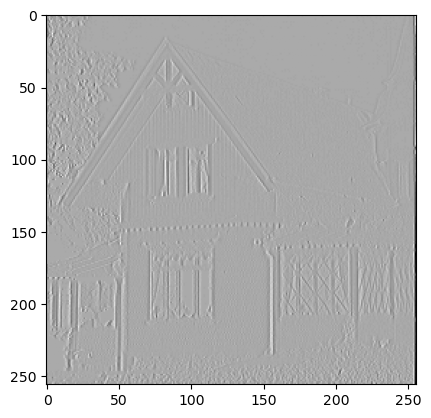

In [206]:
house = np.load("../DD2423_Python_Labs_1_2/Images-npy/godthem256.npy")
# showgrey(discgaussfft(house, 64))

showgrey(convolve2d(house, dxxmask, "same"), 1)

(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)


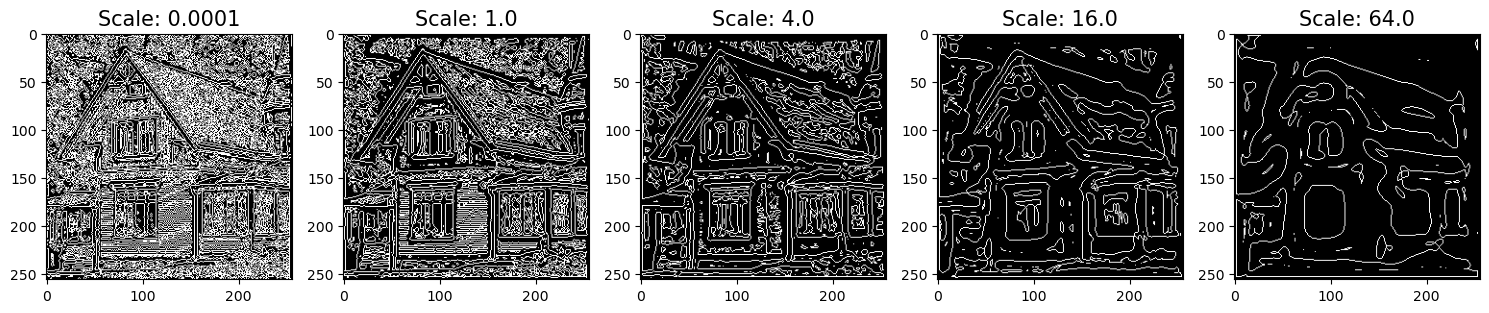

In [225]:
scales = [0.0001, 1.0, 4.0, 16.0, 64.0]
house = np.load("../DD2423_Python_Labs_1_2/Images-npy/godthem256.npy")
im_list = []
titles = []

for i, scale in enumerate(scales):  
    im_list.append(contour(Lvvtilde(discgaussfft(house, scale), 'same')))
    titles.append(f"Scale: {scale}")

create_plots(1, 5, im_list, row_list=None, col_list=titles,figsize_per_image=(3, 3), title_fontsize=15, label_fontsize=15)

(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)
(256, 256) (256, 256) (256, 256)


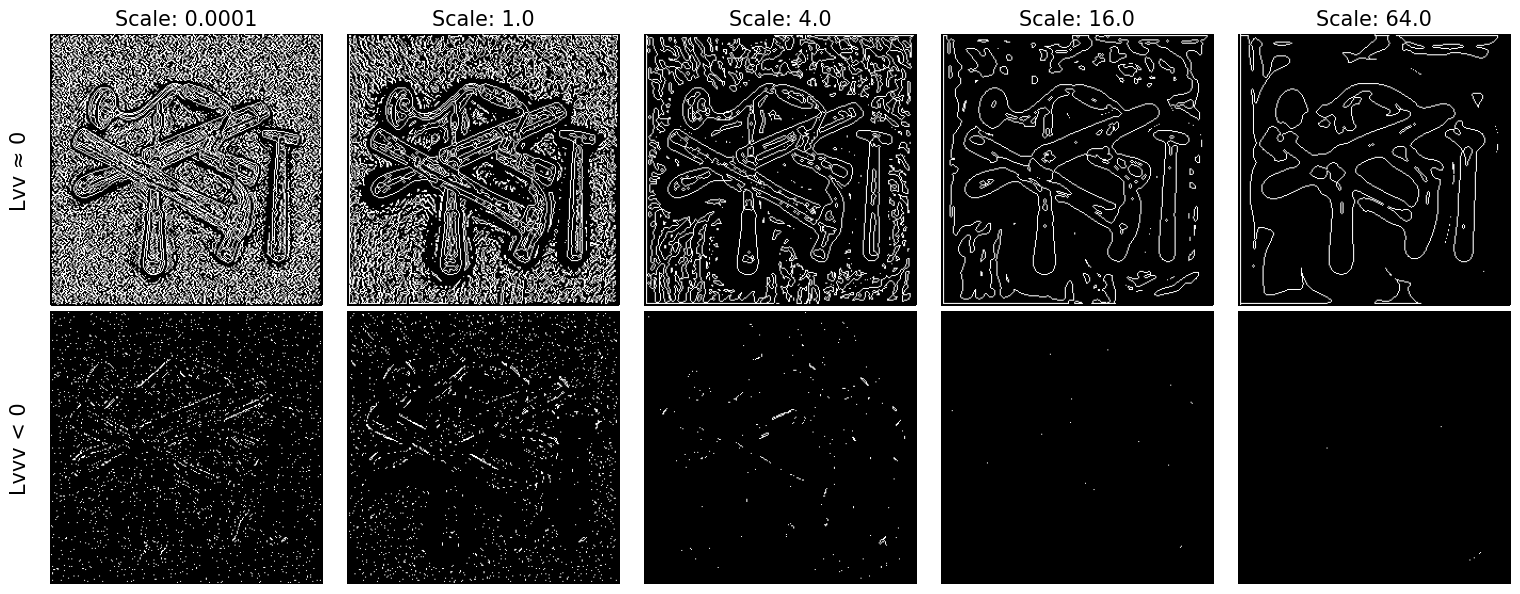

In [246]:
# Question 6:
scales = [0.0001, 1.0, 4.0, 16.0, 64.0]
tools = np.load("../DD2423_Python_Labs_1_2/Images-npy/few256.npy")
im_list = []
col_titles = []
row_titles = []
Lvv_images_tools = []
Lvvv_images_tools = []
Lvv_images_house = []
Lvvv_images_house = []

for i, scale in enumerate(scales):  
    # Lvv_images_house.append(contour(Lvvtilde(discgaussfft(house, scale), 'same')<1e-10).astype(int))
    # Lvvv_images_house.append(contour(Lvvvtilde(discgaussfft(house, scale), 'same')<0).astype(int))
    
    row_titles.append(f"Lvv ≈ 0")
    
    Lvv_images_tools.append(contour(Lvvtilde(discgaussfft(tools, scale), 'same')<1e-10).astype(int))   # almost 0
    
    row_titles.append(f"Lvvv < 0")
    Lvvv_images_tools.append(contour(Lvvvtilde(discgaussfft(tools, scale), 'same')<0).astype(int))
    
    col_titles.append(f"Scale: {scale}")

im_list = Lvv_images_tools + Lvvv_images_tools
create_plots(2, 5, im_list, row_list=row_titles, col_list=col_titles,figsize_per_image=(3, 3), title_fontsize=15, label_fontsize=15)